In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
np.random.seed(42)

rows = 10000

df = pd.DataFrame({
    "Temperature": np.random.randint(15,40,rows),
    "Humidity": np.random.randint(20,90,rows),
    "Occupancy": np.random.randint(1,10,rows),
    "Appliances": np.random.randint(1,20,rows),
    "Hour": np.random.randint(0,24,rows),
    "Previous_Consumption": np.random.uniform(100,500,rows)
})

df["Energy_Consumption"] = (
    df["Previous_Consumption"]*0.45
    + df["Temperature"]*2
    + df["Humidity"]*0.5
    + df["Occupancy"]*5
    + df["Appliances"]*8
    + np.random.normal(0,10,rows)
)
df.to_csv("Energy.csv", index=False)
df.head()


,Temperature,Humidity,Occupancy,Appliances,Hour,Previous_Consumption,Energy_Consumption
0,21,58,9,2,6,159.509791,208.297314
1,34,61,8,6,17,148.640738,268.877278
2,29,67,3,9,22,414.342335,354.832215
3,25,31,5,14,4,377.498361,379.912009
4,22,37,2,8,14,407.171560,308.596145


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           10000 non-null  int32  
 1   Humidity              10000 non-null  int32  
 2   Occupancy             10000 non-null  int32  
 3   Appliances            10000 non-null  int32  
 4   Hour                  10000 non-null  int32  
 5   Previous_Consumption  10000 non-null  float64
 6   Energy_Consumption    10000 non-null  float64
dtypes: float64(2), int32(5)
memory usage: 351.7 KB


In [4]:
df.describe()


,Temperature,Humidity,Occupancy,Appliances,Hour,Previous_Consumption,Energy_Consumption
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,27.134100,54.543600,4.99080,10.010800,11.538500,298.668534,321.089394
std,7.233308,20.216878,2.56304,5.416107,6.975255,115.947604,72.064048
min,15.000000,20.000000,1.00000,1.000000,0.000000,100.006695,107.420346
25%,21.000000,37.000000,3.00000,5.000000,5.000000,197.414854,269.064244
50%,27.000000,55.000000,5.00000,10.000000,11.000000,296.738509,320.909937
75%,33.000000,72.000000,7.00000,15.000000,18.000000,401.030996,372.396272
max,39.000000,89.000000,9.00000,19.000000,23.000000,499.988859,542.589472


In [5]:
df.isnull().sum()

Temperature             0
Humidity                0
Occupancy               0
Appliances              0
Hour                    0
Previous_Consumption    0
Energy_Consumption      0
dtype: int64

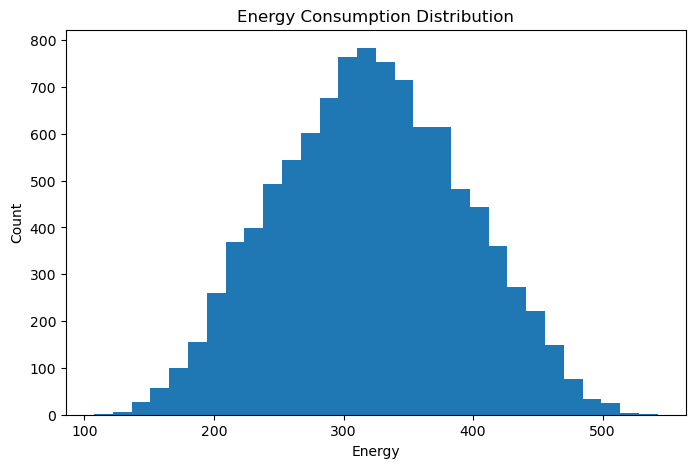

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["Energy_Consumption"], bins=30)
plt.title("Energy Consumption Distribution")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

In [7]:


X = df.drop("Energy_Consumption", axis=1)
y = df["Energy_Consumption"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
print("R2 :", r2_score(y_test,pred))

MAE : 10.078975906252385
RMSE: 12.603038309686719
R2 : 0.9699375580353586


In [10]:
joblib.dump(model, "energy_model.pkl")

['energy_model.pkl']

In [11]:
sample = pd.DataFrame({
    "Temperature":[28],
    "Humidity":[55],
    "Occupancy":[5],
    "Appliances":[10],
    "Hour":[14],
    "Previous_Consumption":[250]
})

prediction = model.predict(sample)

print("Predicted Energy Consumption:", prediction[0])

Predicted Energy Consumption: 290.7088681706662


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 Score:", r2_score(y_test, pred))

MAE: 10.078975906252385
RMSE: 12.603038309686719
R2 Score: 0.9699375580353586


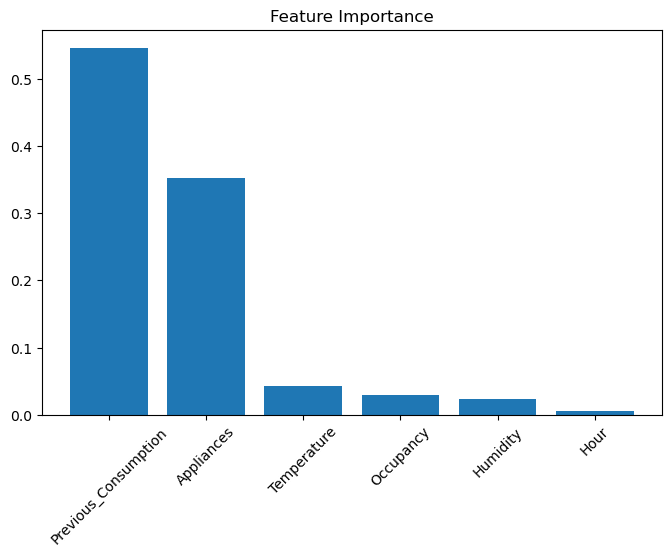

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

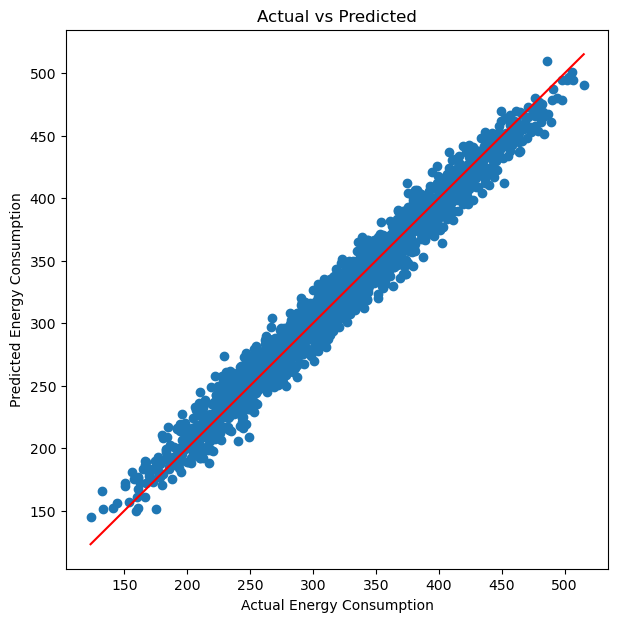

In [14]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, pred)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [15]:
import joblib

joblib.dump(model, "energy_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [16]:
import os

print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.cache', '.conda', '.continuum', '.copilot', '.docker', '.dotnet', '.ghcp-appmod', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.node_repl_history', '.packettracer', '.redhat', '.streamlit', '.templateengine', '.virtual_documents', '.vscode', '17fKi.exe', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Cisco Packet Tracer 9.0.0', 'Contacts', 'Cookies', 'cpy_pandas_tutorial.ipynb', 'data_collection.ipynb', 'desktop', 'Documents', 'Downloads', 'DSA', 'employee_data.csv', 'Energy.csv', 'energy_model.pkl', 'Ew9Ai.exe', 'Favorites', 'globalAirQuality.csv', 'installation', 'Links', 'Local Settings', 'logs', 'lsiXQ.exe', 'Microsoft', 'Music', 'My Documents', 'my_thinking_data.ipynb', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', '